# Model training

Task: classify a profile as empty or person.

The dataset is built in the EDA notebook and saved to
data/processed/final_dataset.csv (131 profiles, 11 rooms). This notebook only loads
it and trains the models.

- Feature set A: the 7 raw echo features.
- Feature set B: residual echo features, the same 7 features after subtracting the empty room.
- Models: Logistic Regression, Random Forest, Gradient Boosting.
- Split: a single 80/20 train/test split.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

feat = pd.read_csv(os.path.join("..", "data", "processed", "final_dataset.csv"))
print("dataset:", feat.shape[0], "profiles x", feat.shape[1], "columns")
print("rooms:", feat.room.nunique(), "| classes:", dict(feat.occupancy.value_counts()))
feat.head()

dataset: 131 profiles x 16 columns
rooms: 11 | classes: {'person': np.int64(66), 'empty': np.int64(65)}


,room,occupancy,raw_peak,raw_peak_dist,raw_near,raw_mid,raw_far,raw_mean,raw_std,res_peak,res_peak_dist,res_near,res_mid,res_far,res_mean,res_std
0,room1,empty,0.011962,210.020833,0.000714,0.003178,0.004334,0.002936,0.003018,5.119999,264.562500,0.172536,1.085454,2.910094,1.517122,2.154013
1,room1,empty,0.001189,210.020833,0.000134,0.000304,0.000585,0.000362,0.000446,6.459861,296.437500,0.252648,2.081540,4.979498,2.663547,2.951578
2,room1,empty,0.039387,296.437500,0.001269,0.008470,0.027058,0.013441,0.020571,15.942300,296.437500,0.409959,2.685552,10.213952,4.874159,8.848458
3,room1,empty,0.020304,264.562500,0.000257,0.003890,0.003408,0.002717,0.003526,5.666851,264.916667,0.192295,1.313423,3.591958,1.857634,2.541487
4,room1,empty,0.010192,172.479167,0.000489,0.003883,0.011096,0.005648,0.004857,3.977157,172.833333,0.156704,0.785920,3.171909,1.504703,1.978392


## Define the models and feature sets

In [2]:
SET_A = [c for c in feat.columns if c.startswith("raw_")]     # raw profile
SET_B = [c for c in feat.columns if c.startswith("res_")]     # residual echo features (after background subtraction)
FEATURE_SETS = {"raw echo features": SET_A, "residual echo features": SET_B}

MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=0),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
}

y = (feat.occupancy == "person").astype(int)
print("feature sets:", list(FEATURE_SETS))
print("models:", list(MODELS))

feature sets: ['raw echo features', 'residual echo features']
models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


## The 80/20 split

In [3]:
idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
print(f"train = {len(tr)} profiles, test = {len(te)} profiles")
print("test class counts:", dict(feat.iloc[te].occupancy.value_counts()))

train = 104 profiles, test = 27 profiles
test class counts: {'person': np.int64(14), 'empty': np.int64(13)}


## Train the models

In [4]:
preds = {}
for fs_name, cols in FEATURE_SETS.items():
    for m_name, model in MODELS.items():
        model.fit(feat[cols].iloc[tr], y.iloc[tr])
        preds[(fs_name, m_name)] = model.predict(feat[cols].iloc[te])
print("trained", len(preds), "model and feature-set combinations")

trained 6 model and feature-set combinations


## Compare the results (accuracy and F1 on the 20% test set)

In [5]:
results = []
for (fs_name, m_name), p in preds.items():
    results.append({"feature set": fs_name, "model": m_name,
                    "accuracy": round(accuracy_score(y.iloc[te], p), 2),
                    "f1": round(f1_score(y.iloc[te], p), 2)})
res = pd.DataFrame(results)
res

,feature set,model,accuracy,f1
0,raw echo features,Logistic Regression,0.52,0.55
1,raw echo features,Random Forest,0.85,0.86
2,raw echo features,Gradient Boosting,0.81,0.83
3,residual echo features,Logistic Regression,0.89,0.88
4,residual echo features,Random Forest,0.89,0.89
5,residual echo features,Gradient Boosting,0.85,0.85


## Best model: confusion matrix

best: Random Forest on residual echo features  (accuracy 0.89, f1 0.89)


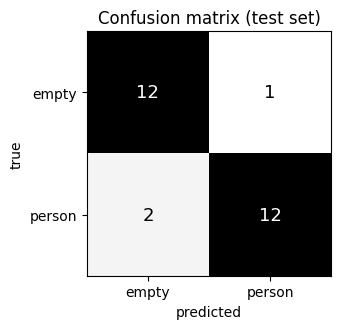

In [6]:
best = res.sort_values(["f1", "accuracy"], ascending=False).iloc[0]
p = preds[(best["feature set"], best["model"])]
print(f"best: {best['model']} on {best['feature set']}  (accuracy {best['accuracy']}, f1 {best['f1']})")
cm = confusion_matrix(y.iloc[te], p)
fig, ax = plt.subplots(figsize=(3.6, 3.4))
ax.imshow(cm, cmap="Greys")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
ax.set_xticks([0,1]); ax.set_xticklabels(["empty","person"])
ax.set_yticks([0,1]); ax.set_yticklabels(["empty","person"])
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.grid(False); ax.set_title("Confusion matrix (test set)")
plt.tight_layout(); plt.show()